# Applying for Ollama API Key

- Go to: https://ollama.com/settings/keys
- Click Add API Key
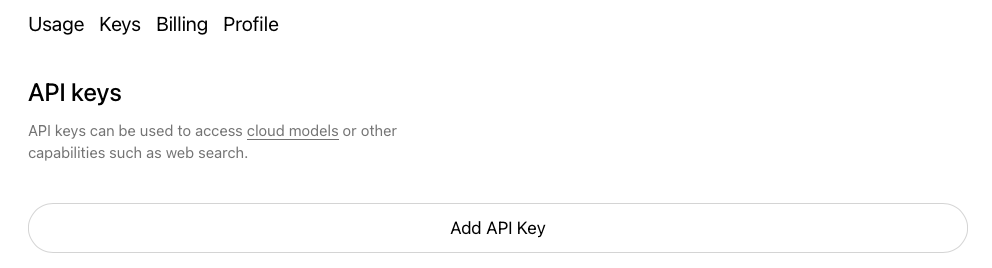

- Name the key and click Generate API Key:
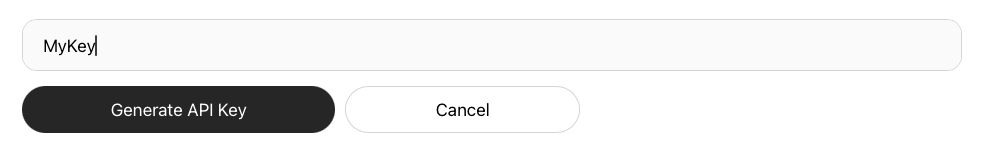

- Copy and save the key to a safe place.

# Using the ollama Package

In [ ]:
!pip install ollama

In [ ]:
import os
os.environ['OLLAMA_API_KEY'] = "xxxxxxxxxxxxxxxxxxx"

In [ ]:
import os
from ollama import Client

client = Client(
    host="https://ollama.com",
    headers={'Authorization': 'Bearer ' + os.environ.get('OLLAMA_API_KEY')}
)

messages = [
  {
    'role': 'user',
    'content': 'Why is the sky blue?',
  },
]

for part in client.chat('gpt-oss:120b', messages=messages, stream=True):
  print(part['message']['content'], end='', flush=True)

# Using cURL

In [ ]:
!curl https://ollama.com/api/chat -H "Authorization: Bearer $OLLAMA_API_KEY" -d '{"model": "gpt-oss:120b","messages": [{"role": "user","content": "Why is the sky blue?"}],"stream": false}'

# Using Requests

In [ ]:
import os
import requests
import json

# Set your API key as an environment variable first
api_key = os.environ.get('OLLAMA_API_KEY')
if not api_key:
    raise ValueError("Please set OLLAMA_API_KEY in your environment variables.")

# Ollama API endpoint
url = "https://ollama.com/api/chat"

# Prepare payload
data = {
    "model": "gpt-oss:120b",  # choose your model
    "messages": [
        {"role": "user", "content": "Why is the sky blue?"}
    ]
}

# HTTP headers
headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

# Send POST request
response = requests.post(url, headers=headers, json=data)
lines = response.text.strip().splitlines()
for line in lines:
    if line:  # skip empty lines
        data = json.loads(line)
        print(data)